# GPU vs CPU Posterior Comparison

**Event:** nb04_event — chirp_mass=20, d=1366 Mpc, lnlike_max≈76, SNR≈11 (realistic O3)

Compares posteriors across four runs to answer two questions:
1. **GPU correctness** — do GPU posteriors agree with CPU at the same bank size?
2. **Bank-size effect** — does moving from 128k to 1M templates shift the posterior?

| Run | Label | Bank | Samples |
|---|---|---|---|
| CPU 128k | `cpu_128k` | 2×64k | 795 |
| GPU 128k | `gpu_128k` | 2×64k | 725 |
| CPU 1M   | `cpu_1M`   | 1M    | 4219 |
| GPU 1M   | `gpu_1M`   | 1M    | 5228 |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import rel_entr

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
sys.path.append("../..")

from cogwheel import gw_plotting

ROOT = Path("../..")
OUTDIR = ROOT / "gpu" / "artifacts" / "comparison"
OUTDIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


In [2]:
RUNS = {
    "cpu_128k": ROOT / "gpu/artifacts/nb04/cpu_j/nb04_event/run_0/samples.feather",
    "gpu_128k": ROOT / "gpu/artifacts/nb04/gpu_j/nb04_event/run_0/samples.feather",
    "cpu_1M":   ROOT / "gpu/artifacts/profile_run/nb05_cpu/nb04_event/run_0/samples.feather",
    "gpu_1M":   ROOT / "gpu/artifacts/profile_run/nb05_gpu/nb04_event/run_0/samples.feather",
}

COLORS = {
    "cpu_128k": "#333333",
    "gpu_128k": "#1f77b4",
    "cpu_1M":   "#d62728",
    "gpu_1M":   "#2ca02c",
}
LINESTYLES = {
    "cpu_128k": "-",
    "gpu_128k": "--",
    "cpu_1M":   "-.",
    "gpu_1M":   ":",
}

def load(path):
    df = pd.read_feather(path)
    df["weights"] = df["weights"] / df["weights"].sum()
    return df

dfs = {k: load(v) for k, v in RUNS.items()}

for k, df in dfs.items():
    print(f"{k:<12}  n={len(df):5d}  n_eff={1/( (df.weights**2).sum() ):.0f}")

cpu_128k      n=  795  n_eff=795
gpu_128k      n=  725  n_eff=725
cpu_1M        n= 4219  n_eff=4219
gpu_1M        n= 5228  n_eff=5228


## 1. Corner plot

Saved: ../../gpu/artifacts/comparison/corner_all.pdf/png


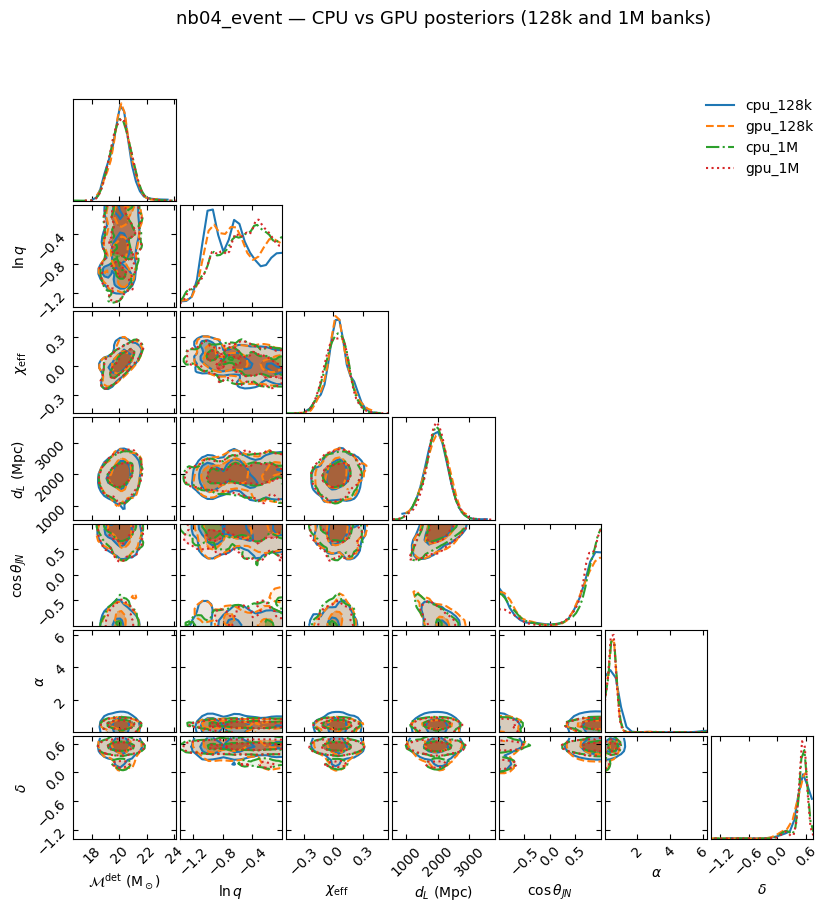

In [3]:
CORNER_PARAMS = ["mchirp", "lnq", "chieff", "d_luminosity", "costheta_jn", "ra", "dec"]

cp = gw_plotting.MultiCornerPlot(
    list(dfs.values()),
    params=CORNER_PARAMS,
    smooth=1.0,
    labels=list(dfs.keys()),
)
cp.plot(max_figsize=9)

fig = plt.gcf()
fig.suptitle("nb04_event — CPU vs GPU posteriors (128k and 1M banks)", y=1.01, fontsize=13)

fig.savefig(OUTDIR / "corner_all.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "corner_all.png", dpi=120, bbox_inches="tight")
print(f"Saved: {OUTDIR}/corner_all.pdf/png")
plt.show()

## 2. 1-D marginal histograms

Saved: ../../gpu/artifacts/comparison/histograms.pdf/png


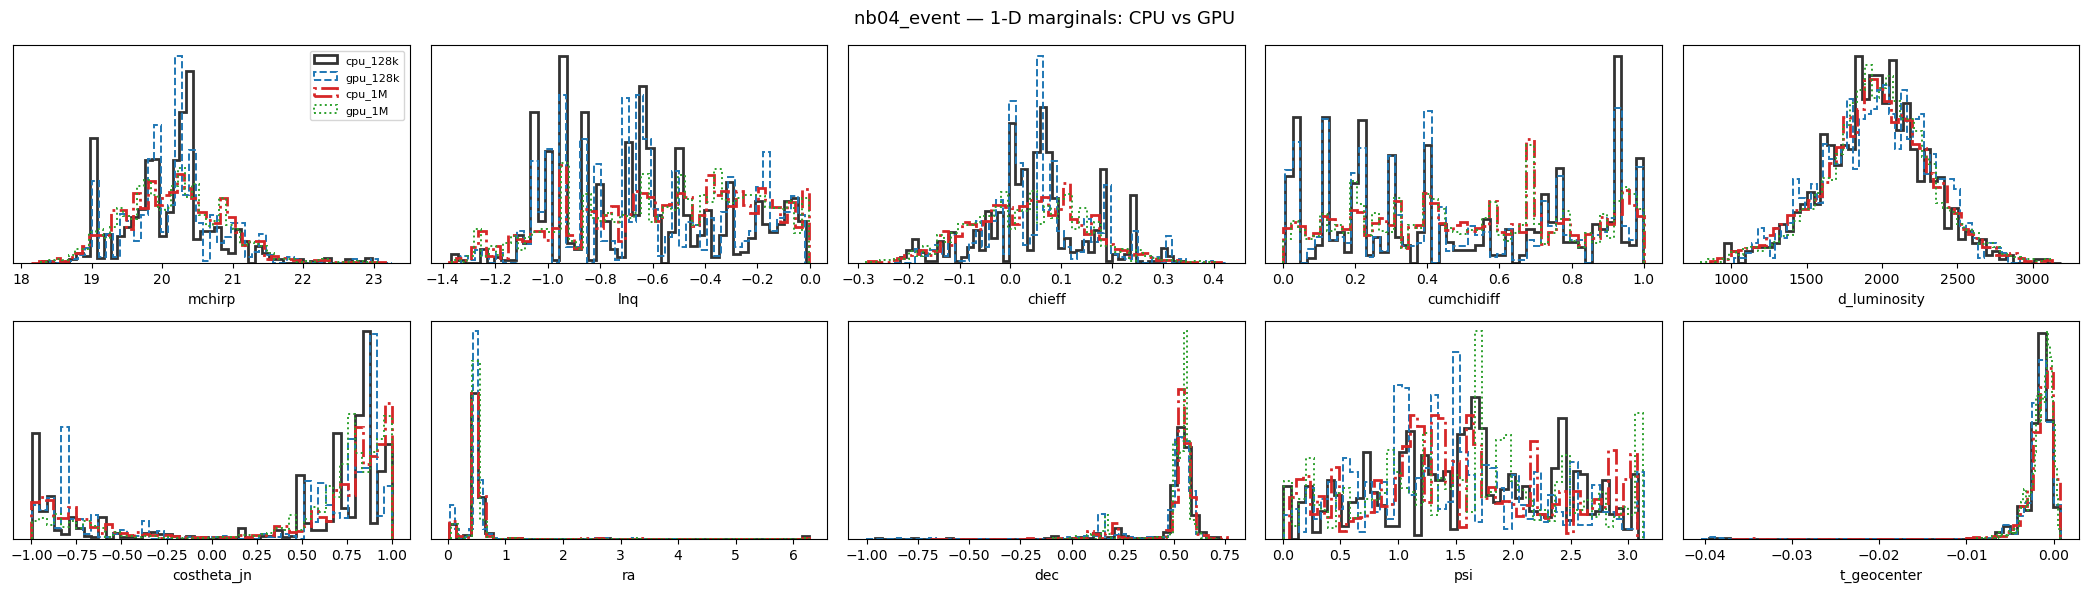

In [4]:
HIST_PARAMS = [
    "mchirp", "lnq", "chieff", "cumchidiff",
    "d_luminosity", "costheta_jn",
    "ra", "dec", "psi", "t_geocenter",
]

ncols = 5
nrows = int(np.ceil(len(HIST_PARAMS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3 * nrows))
axes = axes.ravel()

for ax_idx, param in enumerate(HIST_PARAMS):
    ax = axes[ax_idx]
    for label, df in dfs.items():
        if param not in df.columns:
            continue
        x = df[param].values
        w = df["weights"].values
        lo, hi = np.quantile(x, [0.001, 0.999])
        bins = np.linspace(lo, hi, 50)
        lw = 2.0 if "cpu" in label else 1.4
        ax.hist(x, bins=bins, weights=w, histtype="step",
                color=COLORS[label], linewidth=lw,
                linestyle=LINESTYLES[label], label=label, density=True)
    ax.set_xlabel(param, fontsize=10)
    ax.set_yticks([])
    if ax_idx == 0:
        ax.legend(fontsize=8, loc="upper right")

for ax in axes[len(HIST_PARAMS):]:
    ax.set_visible(False)

fig.suptitle("nb04_event — 1-D marginals: CPU vs GPU", fontsize=13)
fig.tight_layout()
fig.savefig(OUTDIR / "histograms.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "histograms.png", dpi=120, bbox_inches="tight")
print(f"Saved: {OUTDIR}/histograms.pdf/png")
plt.show()

## 3. KS and JS divergences vs CPU 128k reference

In [5]:
def weighted_ks(x1, w1, x2, w2, n_bins=500):
    """KS statistic between two weighted 1-D distributions via CDF on shared grid."""
    lo = min(x1.min(), x2.min())
    hi = max(x1.max(), x2.max())
    grid = np.linspace(lo, hi, n_bins + 1)
    cdf1 = np.array([(w1[x1 <= g]).sum() for g in grid])
    cdf2 = np.array([(w2[x2 <= g]).sum() for g in grid])
    return float(np.abs(cdf1 - cdf2).max())


def js_divergence(x1, w1, x2, w2, n_bins=50):
    """Jensen-Shannon divergence between two weighted 1-D distributions."""
    lo = min(np.quantile(x1, 0.001), np.quantile(x2, 0.001))
    hi = max(np.quantile(x1, 0.999), np.quantile(x2, 0.999))
    bins = np.linspace(lo, hi, n_bins + 1)
    h1, _ = np.histogram(x1, bins=bins, weights=w1)
    h2, _ = np.histogram(x2, bins=bins, weights=w2)
    h1 = h1 / h1.sum() + 1e-12
    h2 = h2 / h2.sum() + 1e-12
    m = 0.5 * (h1 + h2)
    return float(0.5 * (rel_entr(h1, m).sum() + rel_entr(h2, m).sum()))


ref_label = "cpu_128k"
ref_df = dfs[ref_label]
compare_labels = [k for k in dfs if k != ref_label]

rows = []
for param in HIST_PARAMS:
    if param not in ref_df.columns:
        continue
    x_ref = ref_df[param].values
    w_ref = ref_df["weights"].values
    row = {"param": param}
    for lbl in compare_labels:
        df = dfs[lbl]
        if param not in df.columns:
            continue
        x = df[param].values
        w = df["weights"].values
        row[f"KS_{lbl}"] = weighted_ks(x_ref, w_ref, x, w)
        row[f"JS_{lbl}"] = js_divergence(x_ref, w_ref, x, w)
    rows.append(row)

ks_df = pd.DataFrame(rows).set_index("param")

ks_df.to_csv(OUTDIR / "ks_table.csv")
print(f"Reference: {ref_label}")
display(ks_df.round(4))

Reference: cpu_128k


,KS_gpu_128k,JS_gpu_128k,KS_cpu_1M,JS_cpu_1M,KS_gpu_1M,JS_gpu_1M
param,,,,,,
mchirp,0.0409,0.0155,0.1367,0.0619,0.1352,0.0732
lnq,0.0597,0.0167,0.2097,0.1336,0.2149,0.1053
chieff,0.0211,0.0188,0.1545,0.1415,0.1834,0.1047
cumchidiff,0.0448,0.0123,0.1301,0.1232,0.1315,0.1272
d_luminosity,0.0647,0.0158,0.0340,0.0104,0.0433,0.0086
costheta_jn,0.1315,0.1461,0.1255,0.0896,0.1163,0.1099
ra,0.0817,0.0143,0.1083,0.0136,0.1185,0.0157
dec,0.0718,0.0372,0.1070,0.0259,0.1062,0.0497
psi,0.1733,0.0867,0.1160,0.0606,0.0567,0.0606


## 4. KS heatmap

Saved: ../../gpu/artifacts/comparison/ks_heatmap.pdf/png


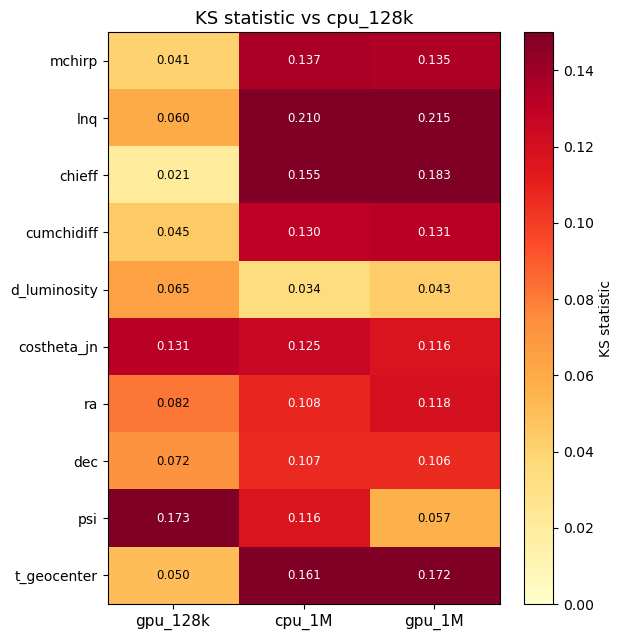

In [6]:
ks_cols = [c for c in ks_df.columns if c.startswith("KS_")]
ks_mat  = ks_df[ks_cols].values
col_labels = [c.replace("KS_", "") for c in ks_cols]

fig, ax = plt.subplots(figsize=(len(ks_cols) * 1.6 + 1.5, len(HIST_PARAMS) * 0.55 + 1.0))
im = ax.imshow(ks_mat, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.15)
plt.colorbar(im, ax=ax, label="KS statistic")

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=11)
ax.set_yticks(range(len(ks_df)))
ax.set_yticklabels(ks_df.index, fontsize=10)

for i in range(ks_mat.shape[0]):
    for j in range(ks_mat.shape[1]):
        ax.text(j, i, f"{ks_mat[i, j]:.3f}",
                ha="center", va="center", fontsize=8.5,
                color="black" if ks_mat[i, j] < 0.09 else "white")

ax.set_title(f"KS statistic vs {ref_label}", fontsize=13)
fig.tight_layout()
fig.savefig(OUTDIR / "ks_heatmap.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "ks_heatmap.png", dpi=120, bbox_inches="tight")
print(f"Saved: {OUTDIR}/ks_heatmap.pdf/png")
plt.show()

## 5. Summary statistics

In [7]:
def weighted_credible_interval(x, w, q_lo=0.05, q_hi=0.95):
    idx = np.argsort(x)
    xs, ws = x[idx], w[idx]
    cdf = np.cumsum(ws)
    med = xs[np.searchsorted(cdf, 0.5)]
    lo  = xs[np.searchsorted(cdf, q_lo)]
    hi  = xs[np.searchsorted(cdf, q_hi)]
    return med, lo, hi


SUMMARY_PARAMS = ["mchirp", "lnq", "chieff", "d_luminosity", "costheta_jn", "ra", "dec"]

summary_rows = []
for param in SUMMARY_PARAMS:
    for label, df in dfs.items():
        if param not in df.columns:
            continue
        x = df[param].values
        w = df["weights"].values
        med, lo, hi = weighted_credible_interval(x, w)
        summary_rows.append({
            "param": param, "run": label,
            "median": med, "ci90_lo": lo, "ci90_hi": hi,
            "ci90_width": hi - lo,
        })

sum_df = pd.DataFrame(summary_rows)
pivot  = sum_df.pivot(index="param", columns="run", values="median")
pivot  = pivot[["cpu_128k", "gpu_128k", "cpu_1M", "gpu_1M"]]

print("Medians (90% CI widths in parentheses):")

width_pivot = sum_df.pivot(index="param", columns="run", values="ci90_width")
width_pivot = width_pivot[["cpu_128k", "gpu_128k", "cpu_1M", "gpu_1M"]]

display(pivot.round(4))
print("\n90% CI widths:")
display(width_pivot.round(4))

sum_df.to_csv(OUTDIR / "summary_stats.csv", index=False)
print(f"\nSaved: {OUTDIR}/summary_stats.csv")

Medians (90% CI widths in parentheses):


run,cpu_128k,gpu_128k,cpu_1M,gpu_1M
param,,,,
chieff,0.0546,0.0546,0.0427,0.0371
costheta_jn,0.7331,0.7085,0.7549,0.7668
d_luminosity,1954.8983,1988.0137,1963.3890,1981.1211
dec,0.5408,0.5396,0.5425,0.5493
lnq,-0.6446,-0.6361,-0.5084,-0.5008
mchirp,20.2194,20.2194,20.1649,20.1568
ra,0.4915,0.4881,0.4851,0.4876



90% CI widths:


run,cpu_128k,gpu_128k,cpu_1M,gpu_1M
param,,,,
chieff,0.3863,0.3560,0.3492,0.3526
costheta_jn,1.9476,1.8739,1.9200,1.8379
d_luminosity,1133.4326,1133.7157,1208.4150,1160.9862
dec,0.3901,0.4634,0.4030,0.4228
lnq,0.9794,0.9827,1.0789,1.0590
mchirp,2.0966,2.2259,2.2579,2.3019
ra,0.4909,0.5342,0.4889,0.4981



Saved: ../../gpu/artifacts/comparison/summary_stats.csv


## 6. Credible-interval comparison plot

Median + 90% CI per parameter, all four runs side by side.

Saved: ../../gpu/artifacts/comparison/ci_comparison.pdf/png


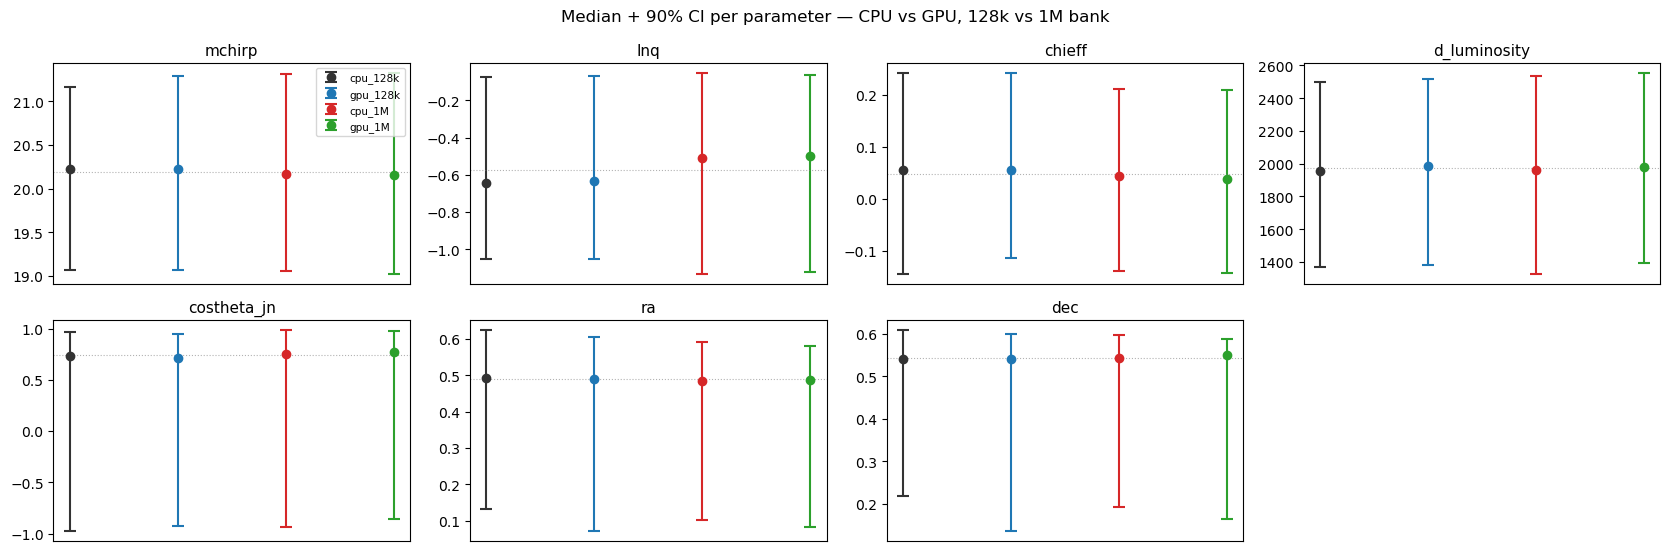

In [8]:
run_order  = ["cpu_128k", "gpu_128k", "cpu_1M", "gpu_1M"]
offsets    = np.array([-0.3, -0.1, 0.1, 0.3])

ncols = 4
nrows = int(np.ceil(len(SUMMARY_PARAMS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.8 * nrows))
axes = axes.ravel()

for ax_idx, param in enumerate(SUMMARY_PARAMS):
    ax = axes[ax_idx]
    sub = sum_df[sum_df["param"] == param].set_index("run")
    for j, (lbl, dx) in enumerate(zip(run_order, offsets)):
        if lbl not in sub.index:
            continue
        row = sub.loc[lbl]
        ax.errorbar(
            dx, row["median"],
            yerr=[[row["median"] - row["ci90_lo"]], [row["ci90_hi"] - row["median"]]],
            fmt="o", color=COLORS[lbl], capsize=4, capthick=1.5,
            markersize=6, linewidth=1.5, label=lbl,
        )
    ax.set_title(param, fontsize=11)
    ax.set_xticks([])
    ax.axhline(sub["median"].mean(), color="gray", lw=0.8, ls=":", alpha=0.6)
    if ax_idx == 0:
        ax.legend(fontsize=7.5, loc="upper right")

for ax in axes[len(SUMMARY_PARAMS):]:
    ax.set_visible(False)

fig.suptitle("Median + 90% CI per parameter — CPU vs GPU, 128k vs 1M bank",
             fontsize=12)
fig.tight_layout()
fig.savefig(OUTDIR / "ci_comparison.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "ci_comparison.png", dpi=120, bbox_inches="tight")
print(f"Saved: {OUTDIR}/ci_comparison.pdf/png")
plt.show()

## 7. PP plot (within-bank)

For each parameter, cumulative probability that the cpu_128k posterior falls
within the gpu_128k credible interval — a flat P-P line indicates consistent
posterior shapes.

Saved: ../../gpu/artifacts/comparison/pp_plots.pdf/png


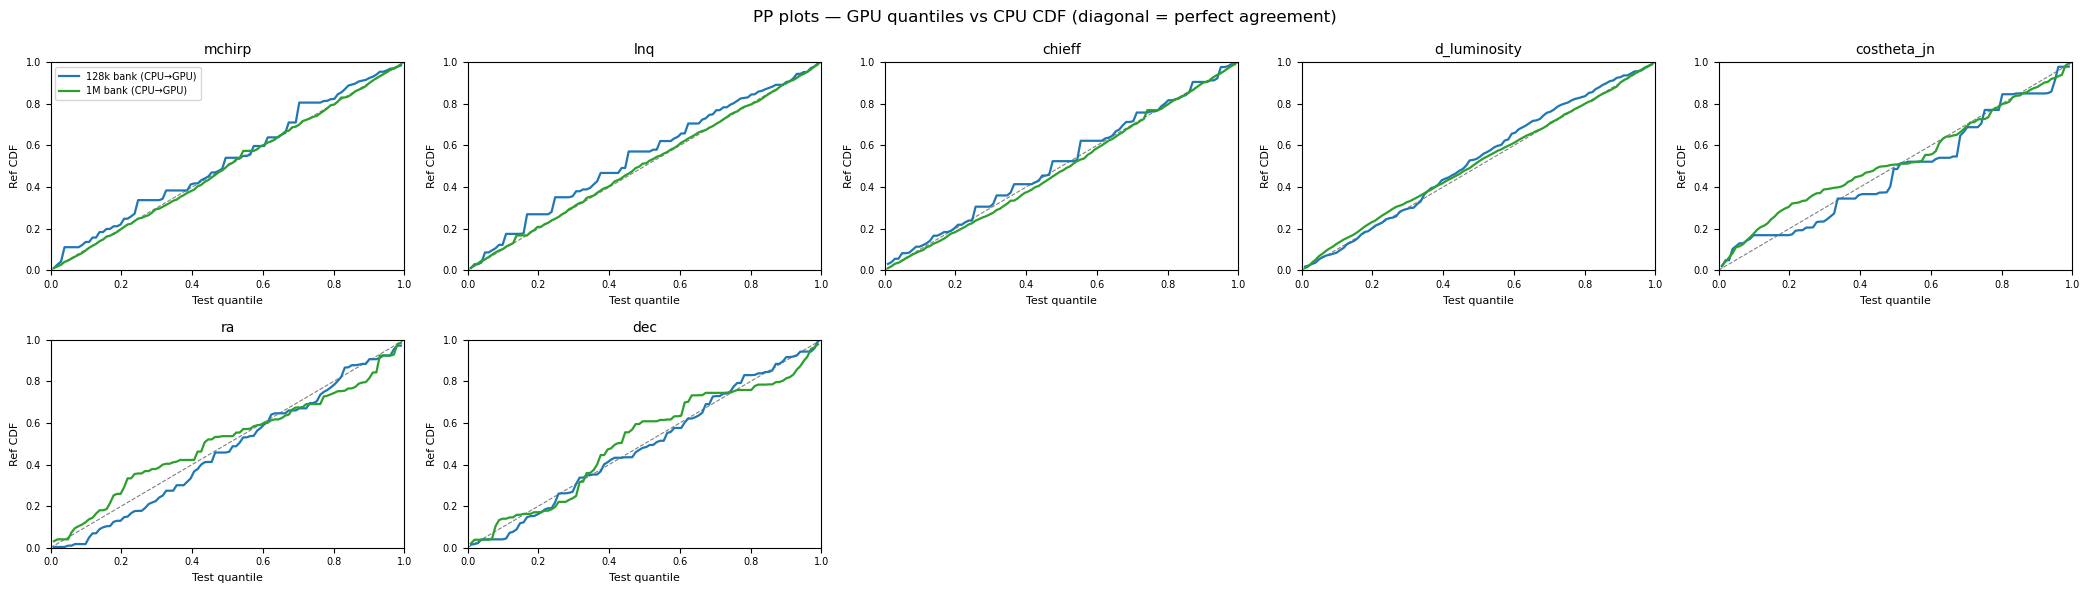

In [9]:
def pp_curve(x_ref, w_ref, x_test, w_test, n_quantiles=100):
    """Fraction of x_ref mass below the q-th quantile of x_test."""
    qs = np.linspace(0, 1, n_quantiles + 2)[1:-1]
    # test quantiles
    idx = np.argsort(x_test)
    xs, ws = x_test[idx], w_test[idx]
    cdf_test = np.cumsum(ws)
    thresholds = xs[np.searchsorted(cdf_test, qs)]
    # ref mass below each threshold
    pp = np.array([(w_ref[x_ref <= t]).sum() for t in thresholds])
    return qs, pp


pairs = [("cpu_128k", "gpu_128k"), ("cpu_1M", "gpu_1M")]
pair_colors = ["#1f77b4", "#2ca02c"]
pair_labels = ["128k bank (CPU→GPU)", "1M bank (CPU→GPU)"]

ncols = 5
nrows = int(np.ceil(len(SUMMARY_PARAMS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows))
axes = axes.ravel()

for ax_idx, param in enumerate(SUMMARY_PARAMS):
    ax = axes[ax_idx]
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    for (lbl_ref, lbl_test), col, plabel in zip(pairs, pair_colors, pair_labels):
        df_ref  = dfs[lbl_ref]
        df_test = dfs[lbl_test]
        if param not in df_ref.columns or param not in df_test.columns:
            continue
        qs, pp = pp_curve(
            df_ref[param].values,  df_ref["weights"].values,
            df_test[param].values, df_test["weights"].values,
        )
        ax.plot(qs, pp, color=col, lw=1.6, label=plabel)
    ax.set_title(param, fontsize=10)
    ax.set_xlabel("Test quantile", fontsize=8)
    ax.set_ylabel("Ref CDF", fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.tick_params(labelsize=7)
    if ax_idx == 0:
        ax.legend(fontsize=7, loc="upper left")

for ax in axes[len(SUMMARY_PARAMS):]:
    ax.set_visible(False)

fig.suptitle("PP plots — GPU quantiles vs CPU CDF (diagonal = perfect agreement)",
             fontsize=12)
fig.tight_layout()
fig.savefig(OUTDIR / "pp_plots.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "pp_plots.png", dpi=120, bbox_inches="tight")
print(f"Saved: {OUTDIR}/pp_plots.pdf/png")
plt.show()

## Summary

| Question | Diagnostic | Expected result |
|---|---|---|
| GPU ≈ CPU at 128k? | KS(gpu_128k, cpu_128k) | < 0.05 on all params |
| GPU ≈ CPU at 1M? | KS(gpu_1M, cpu_1M) | < 0.05 on all params |
| 1M tighter than 128k? | CI width ratio | 1M CI narrower (more bank coverage) |

In [10]:
print("=" * 60)
print("GPU vs CPU consistency (KS statistic, lower = better)")
print("=" * 60)
for param in ["mchirp", "lnq", "chieff", "d_luminosity", "costheta_jn"]:
    if f"KS_gpu_128k" not in ks_df.columns:
        continue
    k128 = ks_df.loc[param, "KS_gpu_128k"]
    k1M  = ks_df.loc[param, "KS_gpu_1M"]
    flag128 = "✓" if k128 < 0.05 else "!"
    flag1M  = "✓" if k1M  < 0.05 else "!"
    print(f"  {param:<18}  GPU_128k KS={k128:.4f} {flag128}   GPU_1M KS={k1M:.4f} {flag1M}")

print()
print("=" * 60)
print("CI width: 1M vs 128k (lower = tighter posterior)")
print("=" * 60)
for param in ["mchirp", "lnq", "chieff", "d_luminosity", "costheta_jn"]:
    w128 = width_pivot.loc[param, "cpu_128k"]
    w1M  = width_pivot.loc[param, "cpu_1M"]
    ratio = w1M / w128
    arrow = "↓" if ratio < 0.95 else ("↑" if ratio > 1.05 else "≈")
    print(f"  {param:<18}  128k={w128:.4f}  1M={w1M:.4f}  ratio={ratio:.2f} {arrow}")

print(f"\nAll outputs saved to: {OUTDIR}")

GPU vs CPU consistency (KS statistic, lower = better)
  mchirp              GPU_128k KS=0.0409 ✓   GPU_1M KS=0.1352 !
  lnq                 GPU_128k KS=0.0597 !   GPU_1M KS=0.2149 !
  chieff              GPU_128k KS=0.0211 ✓   GPU_1M KS=0.1834 !
  d_luminosity        GPU_128k KS=0.0647 !   GPU_1M KS=0.0433 ✓
  costheta_jn         GPU_128k KS=0.1315 !   GPU_1M KS=0.1163 !

CI width: 1M vs 128k (lower = tighter posterior)
  mchirp              128k=2.0966  1M=2.2579  ratio=1.08 ↑
  lnq                 128k=0.9794  1M=1.0789  ratio=1.10 ↑
  chieff              128k=0.3863  1M=0.3492  ratio=0.90 ↓
  d_luminosity        128k=1133.4326  1M=1208.4150  ratio=1.07 ↑
  costheta_jn         128k=1.9476  1M=1.9200  ratio=0.99 ≈

All outputs saved to: ../../gpu/artifacts/comparison
